# House Price Prediction

## Author
Sara Ahmed Farouk Allam

## Project Overview

This project predicts house prices using Machine Learning. The workflow includes:

- Data Loading
- Data Inspection
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- Model Export

# 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

In [2]:
df = pd.read_csv("data/house_prices.csv")

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


# 3. Inspect the Dataset

In [3]:
df.shape

(187531, 21)

In [4]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [7]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

## Dataset Inspection Summary

### Number of Rows and Columns
The dataset contains **187,531 rows** and **21 columns**.

### Numeric Columns
- Index
- Price (in rupees)
- Dimensions
- Plot Area

### Text Columns
- Title
- Description
- Amount(in rupees)
- location
- Carpet Area
- Status
- Floor
- Transaction
- Furnishing
- facing
- overlooking
- Society
- Bathroom
- Balcony
- Car Parking
- Ownership
- Super Area

### Missing Values
The columns with the highest percentage of missing values are:

- Plot Area (100%)
- Dimensions (100%)
- Society (58%)
- Super Area (57%)
- Car Parking (55%)
- overlooking (43%)
- Carpet Area (43%)

# 4. Exploratory Data Analysis (EDA)

## 4.1 Prepare the Price Column

In [8]:
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except ValueError:
        return None

In [9]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,price_clean
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN,4200000.0
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN,9800000.0
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN,14000000.0
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,2500000.0
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN,16000000.0


In [10]:
df["price_clean"].head()

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [11]:
df = df.dropna(subset=["price_clean"])

## 4.2 Price Distribution

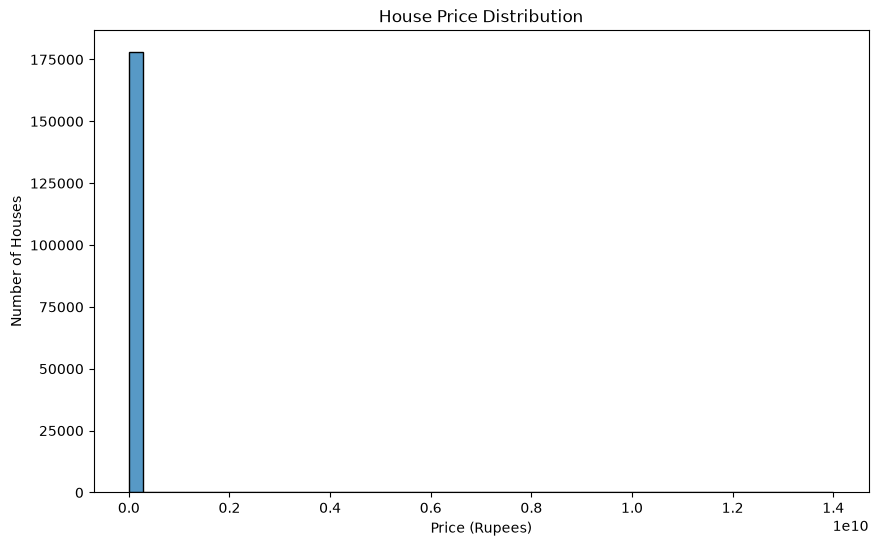

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(df["price_clean"], bins=50)

plt.title("House Price Distribution")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Houses")

plt.show()

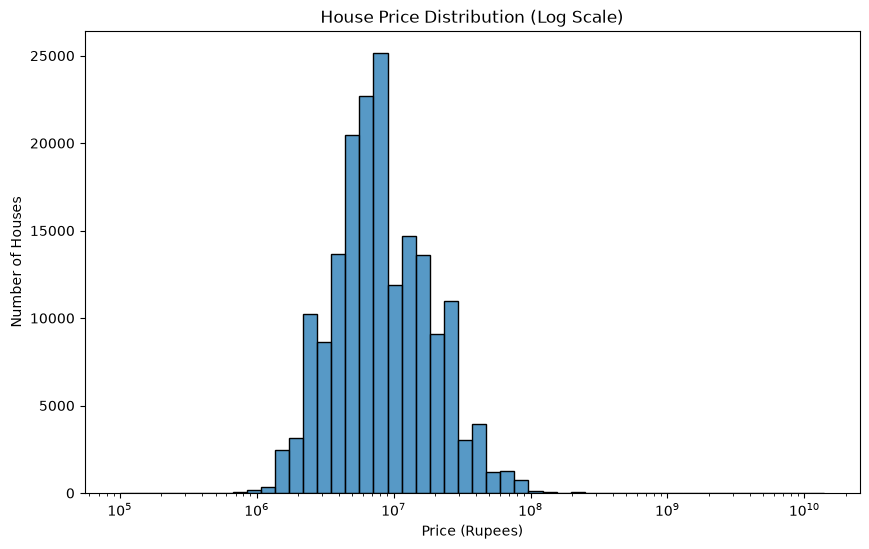

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_clean"],
    bins=50,
    log_scale=True
)

plt.title("House Price Distribution (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Houses")

plt.show()

### Interpretation

- The house prices are not normally distributed.
- Most properties are concentrated around approximately ₹10 million (1 crore).
- A smaller number of luxury properties have much higher prices, creating a long right tail.
- Using a logarithmic scale makes the distribution easier to visualize because it reduces the effect of extremely expensive properties.

## 4.3 Prepare Carpet Area

In [14]:
df["Carpet Area"].head(10)

0    500 sqft
1    473 sqft
2    779 sqft
3    530 sqft
4    635 sqft
5         NaN
6    550 sqft
7         NaN
8         NaN
9    900 sqft
Name: Carpet Area, dtype: str

In [15]:
df["Carpet Area"].value_counts().head(20)

Carpet Area
1000 sqft    5223
900 sqft     4616
1300 sqft    3446
1600 sqft    2737
600 sqft     2210
1500 sqft    2130
950 sqft     1912
1250 sqft    1651
400 sqft     1641
850 sqft     1637
1700 sqft    1544
1400 sqft    1499
1050 sqft    1361
750 sqft     1319
1200 sqft    1296
1450 sqft    1295
1350 sqft    1289
1800 sqft    1104
1100 sqft    1101
800 sqft     1062
Name: count, dtype: int64

## 4.4 Clean Carpet Area

In [16]:
import re

def parse_area(area):
    if pd.isna(area):
        return np.nan

    area = str(area).lower().strip()

    # Extract the first number
    match = re.search(r"(\d+\.?\d*)", area)

    if not match:
        return np.nan

    value = float(match.group(1))

    # Convert square meters to square feet
    if "sqm" in area:
        value *= 10.764

    return value

In [17]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

In [18]:
df[["Carpet Area", "carpet_area_sqft"]].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [19]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

## 4.5 Price vs Carpet Area

In [20]:
sample_df = df.sample(5000, random_state=42)

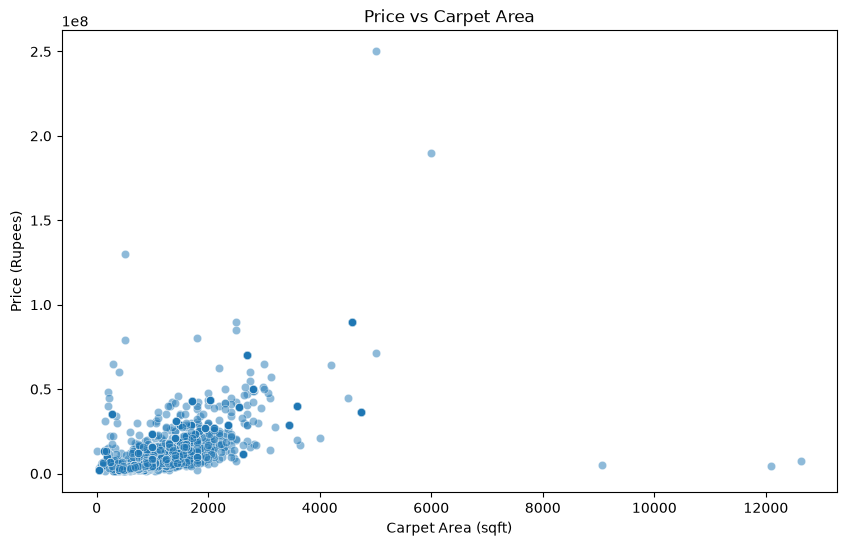

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.5
)

plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")

plt.show()

### Interpretation

- There is a positive relationship between carpet area and house price.
- In general, larger houses tend to have higher prices.
- Most houses are concentrated below approximately 3,000 sqft.
- A few properties have exceptionally large areas or prices, indicating potential outliers.

In [22]:
plot_df = sample_df[
    (sample_df["carpet_area_sqft"] < 5000) &
    (sample_df["price_clean"] < 60000000)
]

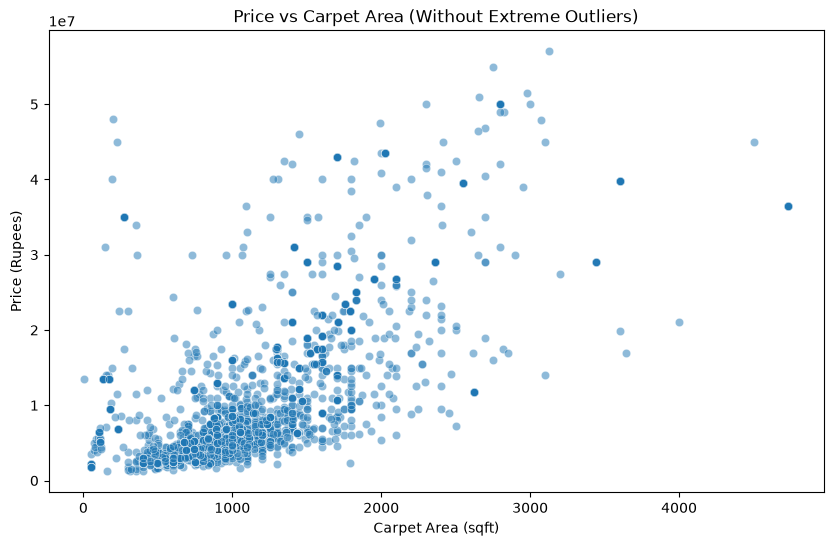

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.5
)

plt.title("Price vs Carpet Area (Without Extreme Outliers)")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")

plt.show()

## 4.6 Average Price by Location

In [24]:
df["location"].nunique()

81

In [25]:
df["location"].value_counts().head(15)

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
Name: count, dtype: int64

In [26]:
top_locations = df["location"].value_counts().head(15).index

location_df = df[df["location"].isin(top_locations)]

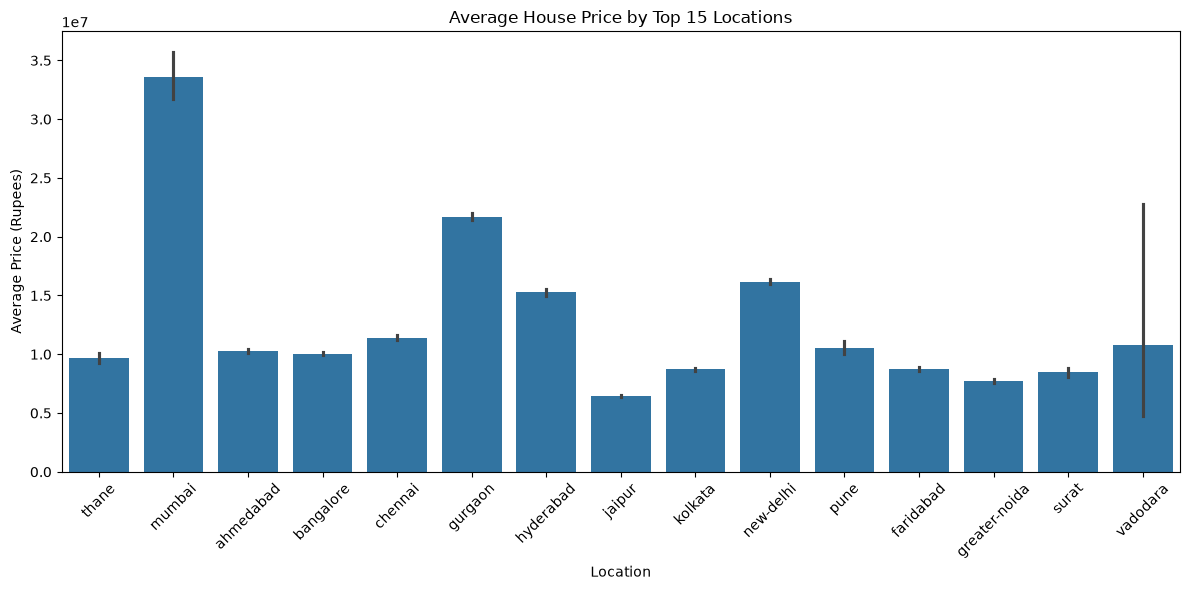

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=location_df,
    x="location",
    y="price_clean",
    estimator="mean"
)

plt.xticks(rotation=45)

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price (Rupees)")

plt.tight_layout()

plt.show()

### Interpretation

- Mumbai has the highest average house price among the top 15 locations.
- Gurgaon and New Delhi also have relatively high average prices.
- Jaipur, Greater Noida, and Surat have lower average prices.


## 4.7 Price by Furnishing

In [28]:
df["Furnishing"].value_counts()

Furnishing
Semi-Furnished    82868
Unfurnished       73491
Furnished         19421
Name: count, dtype: int64

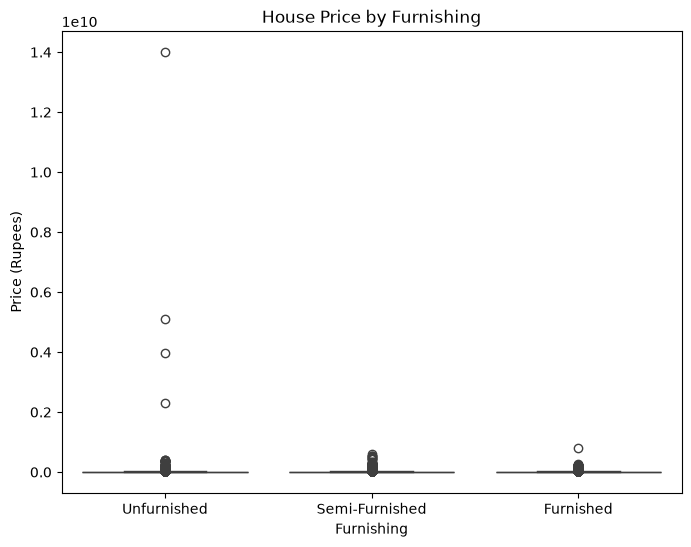

In [29]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.title("House Price by Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Price (Rupees)")

plt.show()

In [30]:
plot_df = df[df["price_clean"] < 60000000]

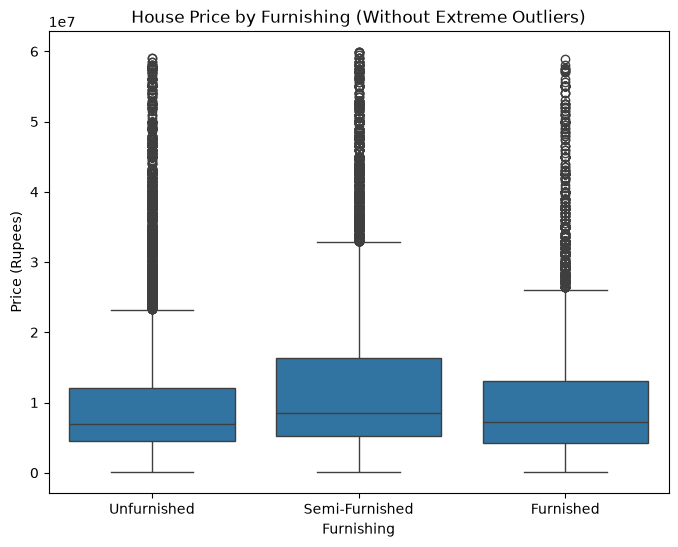

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=plot_df,
    x="Furnishing",
    y="price_clean"
)

plt.title("House Price by Furnishing (Without Extreme Outliers)")
plt.xlabel("Furnishing")
plt.ylabel("Price (Rupees)")

plt.show()

### Interpretation

- Semi-Furnished properties are the most common in the dataset.
- Unfurnished properties are also common, while Furnished properties are fewer.
- The boxplot suggests that furnished properties generally tend to have higher prices.
- A number of extreme price outliers are present across all furnishing categories.

# 5. Data Cleaning

## 5.1 Remove Unnecessary Columns

In [32]:
columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Amount(in rupees)",
    "Price (in rupees)",
    "Carpet Area",
    "Dimensions",
    "Plot Area"
]

df = df.drop(columns=columns_to_drop)

In [33]:
df.columns

Index(['location', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking',
       'Ownership', 'Super Area', 'price_clean', 'carpet_area_sqft'],
      dtype='str')

In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          177847 non-null  str    
 1   Status            177252 non-null  str    
 2   Floor             170898 non-null  str    
 3   Transaction       177780 non-null  str    
 4   Furnishing        175780 non-null  str    
 5   facing            112111 non-null  str    
 6   overlooking       102022 non-null  str    
 7   Society           74928 non-null   str    
 8   Bathroom          177087 non-null  str    
 9   Balcony           130688 non-null  str    
 10  Car Parking       81935 non-null   str    
 11  Ownership         115922 non-null  str    
 12  Super Area        76235 non-null   str    
 13  price_clean       177847 non-null  float64
 14  carpet_area_sqft  101522 non-null  float64
dtypes: float64(2), str(13)
memory usage: 21.7 MB


## 5.2 Handle Missing Values

In [35]:
missing = df.isna().mean() * 100

missing.sort_values(ascending=False)

Society             57.869405
Super Area          57.134503
Car Parking         53.929501
carpet_area_sqft    42.916102
overlooking         42.634962
facing              36.962108
Ownership           34.819255
Balcony             26.516613
Floor                3.907291
Furnishing           1.162235
Bathroom             0.427334
Status               0.334557
Transaction          0.037673
location             0.000000
price_clean          0.000000
dtype: float64

In [36]:
high_missing_columns = [
    "Society",
    "Super Area",
    "Car Parking"
]

df = df.drop(columns=high_missing_columns)

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          177847 non-null  str    
 1   Status            177252 non-null  str    
 2   Floor             170898 non-null  str    
 3   Transaction       177780 non-null  str    
 4   Furnishing        175780 non-null  str    
 5   facing            112111 non-null  str    
 6   overlooking       102022 non-null  str    
 7   Bathroom          177087 non-null  str    
 8   Balcony           130688 non-null  str    
 9   Ownership         115922 non-null  str    
 10  price_clean       177847 non-null  float64
 11  carpet_area_sqft  101522 non-null  float64
dtypes: float64(2), str(10)
memory usage: 17.6 MB


In [38]:
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(
    df["carpet_area_sqft"].median()
)

In [39]:
categorical_columns = [
    "Floor",
    "Furnishing",
    "Bathroom",
    "Balcony",
    "Ownership",
    "facing",
    "overlooking",
    "Status",
    "Transaction"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [40]:
df.isna().sum()

location            0
Status              0
Floor               0
Transaction         0
Furnishing          0
facing              0
overlooking         0
Bathroom            0
Balcony             0
Ownership           0
price_clean         0
carpet_area_sqft    0
dtype: int64

## 5.3 Convert Numeric Text Columns

In [41]:
df.dtypes

location                str
Status                  str
Floor                   str
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Bathroom                str
Balcony                 str
Ownership               str
price_clean         float64
carpet_area_sqft    float64
dtype: object

In [42]:
df["Bathroom"].value_counts().head(20)

Bathroom
2       89759
3       54187
1       15509
4       14826
5        3281
6         187
7          32
> 10       29
8          14
10         12
9          11
Name: count, dtype: int64

In [43]:
df["Balcony"].value_counts().head(20)

Balcony
2       97470
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
9           2
Name: count, dtype: int64

In [44]:
df["Floor"].value_counts().head(20)

Floor
1 out of 4          18750
2 out of 4          11437
3 out of 4           7804
1 out of 3           6934
2 out of 3           5868
4 out of 4           5814
3 out of 3           4405
2 out of 5           4331
4 out of 5           3723
3 out of 6           3579
3 out of 5           3360
2 out of 2           3350
1 out of 5           3319
1 out of 2           2829
Ground out of 4      2778
5 out of 5           2405
8 out of 10          2381
Ground out of 10     2154
3 out of 10          1967
4 out of 8           1888
Name: count, dtype: int64

In [45]:
df.dtypes

location                str
Status                  str
Floor                   str
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Bathroom                str
Balcony                 str
Ownership               str
price_clean         float64
carpet_area_sqft    float64
dtype: object

In [46]:
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [47]:
df.dtypes

location                str
Status                  str
Floor                   str
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Bathroom            float64
Balcony             float64
Ownership               str
price_clean         float64
carpet_area_sqft    float64
dtype: object

### 5.4 Parse Floor Column

In [48]:
df["Floor"].value_counts().head(20)

Floor
1 out of 4          18750
2 out of 4          11437
3 out of 4           7804
1 out of 3           6934
2 out of 3           5868
4 out of 4           5814
3 out of 3           4405
2 out of 5           4331
4 out of 5           3723
3 out of 6           3579
3 out of 5           3360
2 out of 2           3350
1 out of 5           3319
1 out of 2           2829
Ground out of 4      2778
5 out of 5           2405
8 out of 10          2381
Ground out of 10     2154
3 out of 10          1967
4 out of 8           1888
Name: count, dtype: int64

In [49]:
import re
import numpy as np

def parse_floor(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower()

    if "ground" in value:
        return 0

    if "basement" in value:
        return -1

    match = re.search(r"\d+", value)

    if match:
        return int(match.group())

    return np.nan

In [50]:
df["floor_num"] = df["Floor"].apply(parse_floor)

In [51]:
df[["Floor","floor_num"]].head(20)

,Floor,floor_num
0,10 out of 11,10
1,3 out of 22,3
2,10 out of 29,10
3,1 out of 3,1
4,20 out of 42,20
5,2 out of 7,2
6,4 out of 5,4
7,Ground out of 7,0
8,Ground out of 2,0
9,3 out of 27,3


In [52]:
df["floor_num"] = df["floor_num"].fillna(
    df["floor_num"].median()
)

In [53]:
df.drop(columns=["Floor"], inplace=True)

# 6. Model Preparation

## 6.1 Select Features and Target

In [54]:
X = df.drop(columns=["price_clean"])
y = df["price_clean"]

In [55]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (177847, 11)
Target shape: (177847,)


In [56]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [57]:
X.head()

,Bathroom,Balcony,carpet_area_sqft,floor_num,location_ahmadnagar,location_ahmedabad,location_allahabad,location_aurangabad,location_badlapur,location_bangalore,...,"overlooking_Main Road, Pool, Garden/Park",overlooking_Pool,"overlooking_Pool, Garden/Park","overlooking_Pool, Garden/Park, Main Road","overlooking_Pool, Main Road","overlooking_Pool, Main Road, Garden/Park","overlooking_Pool, Main Road, Not Available",Ownership_Freehold,Ownership_Leasehold,Ownership_Power Of Attorney
0,1.0,2.0,500.0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2.0,2.0,473.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2.0,2.0,779.0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1.0,1.0,530.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2.0,2.0,635.0,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
X.dtypes

Bathroom                                      float64
Balcony                                       float64
carpet_area_sqft                              float64
floor_num                                       int64
location_ahmadnagar                             int64
                                               ...   
overlooking_Pool, Main Road, Garden/Park        int64
overlooking_Pool, Main Road, Not Available      int64
Ownership_Freehold                              int64
Ownership_Leasehold                             int64
Ownership_Power Of Attorney                     int64
Length: 116, dtype: object

## 6.2 Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (142277, 116)
Testing set: (35570, 116)


# 7. Model Training

## 7.1 Linear Regression


In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
lr_model = LinearRegression()

In [64]:
X.isna().sum().sort_values(ascending=False).head(20)

Bathroom                29
Balcony                 16
carpet_area_sqft         0
floor_num                0
location_ahmadnagar      0
location_ahmedabad       0
location_allahabad       0
location_aurangabad      0
location_badlapur        0
location_bangalore       0
location_belgaum         0
location_bhiwadi         0
location_bhiwandi        0
location_bhopal          0
location_bhubaneswar     0
location_chandigarh      0
location_chennai         0
location_coimbatore      0
location_dehradun        0
location_durgapur        0
dtype: int64

In [65]:
df.isna().sum()

location             0
Status               0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Bathroom            29
Balcony             16
Ownership            0
price_clean          0
carpet_area_sqft     0
floor_num            0
dtype: int64

In [66]:
df["Bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["Balcony"] = df["Balcony"].fillna(df["Balcony"].median())

In [67]:
X = df.drop(columns=["price_clean"])
y = df["price_clean"]


In [68]:
print(X.columns.tolist())

['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom', 'Balcony', 'Ownership', 'carpet_area_sqft', 'floor_num']


In [69]:

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](116,)","[ 8909168.77, 1312370.09, 215.3 ,..., 2033592.2 , 893874.76, -1127780.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](116,)","['Bathroom','Balcony','carpet_area_sqft',...,'Ownership_Freehold', 'Ownership_Leasehold','Ownership_Power Of Attorney']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.717e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(116)


## 7.2 Make Predictions

In [72]:
y_pred_lr = lr_model.predict(X_test)

In [73]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_lr
})

comparison.head(10)

,Actual Price,Predicted Price
0,13000000.0,1.766900e+07
1,4300000.0,1.499682e+06
2,6000000.0,7.195256e+06
3,19200000.0,2.468298e+07
4,4500000.0,6.430955e+06
5,3250000.0,7.334725e+06
6,21100000.0,2.404312e+07
7,1900000.0,-6.212591e+06
8,6000000.0,9.341581e+06
9,2200000.0,-3.227287e+06


In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [75]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 5,730,319.12
RMSE: 75,759,413.73
R²  : 0.0171


In [76]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,5.730319e+06,7.575941e+07,0.017098


## 7.3 Random Forest Regressor

In [77]:
from sklearn.ensemble import RandomForestRegressor

In [78]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [79]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [80]:
y_pred_rf = rf_model.predict(X_test)

In [81]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")

MAE : 1,924,213.03
RMSE: 76,323,387.85
R²  : 0.0024


In [82]:
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_rf
    ],
    "R²": [
        r2,
        r2_rf
    ]
})

comparison_results

,Model,MAE,RMSE,R²
0,Linear Regression,5.730319e+06,7.575941e+07,0.017098
1,Random Forest,1.924213e+06,7.632339e+07,0.002409


# 9. Save the Model

In [83]:
import joblib
import os

In [84]:
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']

In [85]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [86]:
import json

locations = sorted(df["location"].unique())

with open("../models/locations.json", "w") as f:
    json.dump(locations, f)

In [87]:
os.listdir("../models")

['feature_columns.pkl', 'house_price_model.pkl', 'locations.json']

In [88]:
loaded_model = joblib.load("../models/house_price_model.pkl")

type(loaded_model)

sklearn.ensemble._forest.RandomForestRegressor

In [89]:
loaded_model.predict(X_test.iloc[:1])

array([13000000.])

In [90]:
import joblib

feature_columns = joblib.load("../models/feature_columns.pkl")

print(feature_columns[:50])

['Bathroom', 'Balcony', 'carpet_area_sqft', 'floor_num', 'location_ahmadnagar', 'location_ahmedabad', 'location_allahabad', 'location_aurangabad', 'location_badlapur', 'location_bangalore', 'location_belgaum', 'location_bhiwadi', 'location_bhiwandi', 'location_bhopal', 'location_bhubaneswar', 'location_chandigarh', 'location_chennai', 'location_coimbatore', 'location_dehradun', 'location_durgapur', 'location_ernakulam', 'location_faridabad', 'location_ghaziabad', 'location_goa', 'location_greater-noida', 'location_guntur', 'location_gurgaon', 'location_guwahati', 'location_gwalior', 'location_haridwar', 'location_hyderabad', 'location_indore', 'location_jabalpur', 'location_jaipur', 'location_jamshedpur', 'location_jodhpur', 'location_kalyan', 'location_kanpur', 'location_kochi', 'location_kolkata', 'location_kozhikode', 'location_lucknow', 'location_ludhiana', 'location_madurai', 'location_mangalore', 'location_mohali', 'location_mumbai', 'location_mysore', 'location_nagpur', 'locatio

In [91]:
import joblib

feature_columns = joblib.load("../models/feature_columns.pkl")

for col in feature_columns:
    if (
        col.startswith("Status")
        or col.startswith("Transaction")
        or col.startswith("Furnishing")
        or col.startswith("Ownership")
        or col.startswith("facing")
        or col.startswith("overlooking")
    ):
        print(col)

Transaction_Other
Transaction_Rent/Lease
Transaction_Resale
Furnishing_Semi-Furnished
Furnishing_Unfurnished
facing_North
facing_North - East
facing_North - West
facing_South
facing_South - East
facing_South -West
facing_West
overlooking_Garden/Park, Main Road
overlooking_Garden/Park, Main Road, Pool
overlooking_Garden/Park, Not Available
overlooking_Garden/Park, Pool
overlooking_Garden/Park, Pool, Main Road
overlooking_Main Road
overlooking_Main Road, Garden/Park
overlooking_Main Road, Garden/Park, Pool
overlooking_Main Road, Not Available
overlooking_Main Road, Pool
overlooking_Main Road, Pool, Garden/Park
overlooking_Pool
overlooking_Pool, Garden/Park
overlooking_Pool, Garden/Park, Main Road
overlooking_Pool, Main Road
overlooking_Pool, Main Road, Garden/Park
overlooking_Pool, Main Road, Not Available
Ownership_Freehold
Ownership_Leasehold
Ownership_Power Of Attorney
